### Modelo de clasificación: Machine Learning no supervisado


1. Carga y Preparación de Datos

Este paso incluye la codificación de variables categóricas, el manejo de valores nulos, la selección de variables y el escalado, excluyendo la columna "risk_class" del agrupamiento.

In [2]:
import pandas as pd
#from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# --- 1. Carga y Limpieza Inicial ---
df = pd.read_csv(r"C:\Users\jprom\Desktop\IT Academy\Proyecto Final\Data\Master_Data_Set_Final.csv")

# Convertir la columna de riesgo a entero (si es necesario)
df['risk_class'] = df['risk_class'].fillna(0).astype(int)

# --- 2. Codificación One-Hot de Variables Categóricas ---
# Seleccionamos las columnas a incluir en el clustering (todas excepto IDs, resultado final, y riesgo)
#categorical_cols = ['gender']
numerical_cols = ['num_of_prev_attempts', 'studied_credits', 'module_presentation_length', 
                  'avg_initial_score', 'first_eval_score', 'total_clicks_acum', 'total_active_days']

# Crea el DataFrame de características (excluyendo IDs, final_result y risk_class)
#df_features = df[['id_student'] + """categorical_cols""" + numerical_cols].copy()
df_features = df[['id_student'] + numerical_cols].copy()

# Aplica One-Hot Encoding a las variables categóricas
#df_encoded = pd.get_dummies(df_features, columns=categorical_cols, drop_first=True)
df_encoded = pd.get_dummies(df_features, drop_first=True)

# Manejar valores nulos (por si hay nulos remanentes en numéricas)
df_encoded = df_encoded.fillna(df_encoded.mean())

# --- 3. Escalado de Características ---
# Excluimos 'id_student' para el escalado
features_for_scaling = df_encoded.drop(columns=['id_student']).columns

scaler = Normalizer() #mirar alternativa outliers
scaled_features = scaler.fit_transform(df_encoded[features_for_scaling])

# Convertir de nuevo a DataFrame
df_scaled = pd.DataFrame(scaled_features, index=df_encoded.index, columns=features_for_scaling)
print("DataFrame escalado listo para K-Means.")

DataFrame escalado listo para K-Means.


2. Determinación del $K$ Óptimo (Método del Codo)

Utilizaremos el Método del Codo (Elbow Method) para sugerir un número apropiado de clusters ($K$).

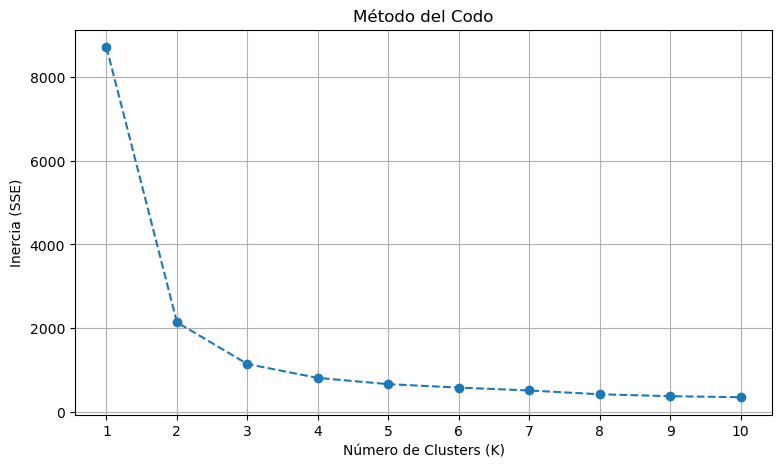


Observar el gráfico y elegir el valor de K en el 'codo' de la curva.


In [3]:
# --- 4. Método del Codo para encontrar el K óptimo ---
inertia = []
K_range = range(1, 11) # Probando de 1 a 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (SSE)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

print("\nObservar el gráfico y elegir el valor de K en el 'codo' de la curva.")

optimal_k = 4

3. Aplicación de K-Means y Asignación de Clusters

Aplicamos el algoritmo K-Means con el $K$ seleccionado y adjuntamos las etiquetas de cluster al DataFrame original para su análisis.

In [4]:
# --- 5. Aplicación del K-Means Final ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_final.fit(df_scaled)

# Asignar la etiqueta de cluster al DataFrame original de características
df_encoded['Cluster'] = kmeans_final.labels_

# Unir la etiqueta de cluster con las columnas 'risk_class' y 'id_student' del DF original
df_final = df_encoded.merge(df[['id_student', 'risk_class']], on='id_student', how='left')

# --- 6. Perfilado de Clusters (Centros de Cluster) ---
# Usamos las medias de las características ESCALADAS para el Radar Chart
cluster_profile_scaled = df_final.groupby('Cluster')[features_for_scaling].mean()

print(f"\nSe han creado {optimal_k} clusters.")
print("\nPerfil de los Clusters (medias de las características escaladas - Z-Scores):\n", cluster_profile_scaled.head())

# --- 7. Análisis de la Clase de Riesgo por Cluster ---
print("\n--- Análisis de Clase de Riesgo por Cluster ---")
risk_analysis = df_final.groupby('Cluster')['risk_class'].value_counts(normalize=True).mul(100).unstack(fill_value=0)
risk_analysis.columns = ['Fracaso (0) %', 'Éxito (1) %']
risk_analysis


Se han creado 4 clusters.

Perfil de los Clusters (medias de las características escaladas - Z-Scores):
          num_of_prev_attempts  studied_credits  module_presentation_length  \
Cluster                                                                      
0                    0.130730        76.614251                  256.562725   
1                    0.272664        95.100023                  255.465310   
2                    0.269868        84.123227                  255.651513   
3                    0.190670        77.973092                  255.788597   

         avg_initial_score  first_eval_score  total_clicks_acum  \
Cluster                                                           
0                76.499130         76.093826        2452.660613   
1                 7.273936          7.331869          17.696230   
2                52.501880         52.847718         181.244744   
3                66.017755         65.597155         520.895787   

         total_active_

,Fracaso (0) %,Éxito (1) %
Cluster,,
0,26.430312,73.569688
1,95.235893,4.764107
2,81.080157,18.919843
3,54.697839,45.302161


In [5]:
df_final.to_csv('Master_Data_Set_Clusters.csv')

4. Visualización con Gráfico de Radar

Usamos los centroides escalados (cluster_profile_scaled) para generar los gráficos de radar, uno por cluster, facilitando la identificación de las variables de alto impacto.

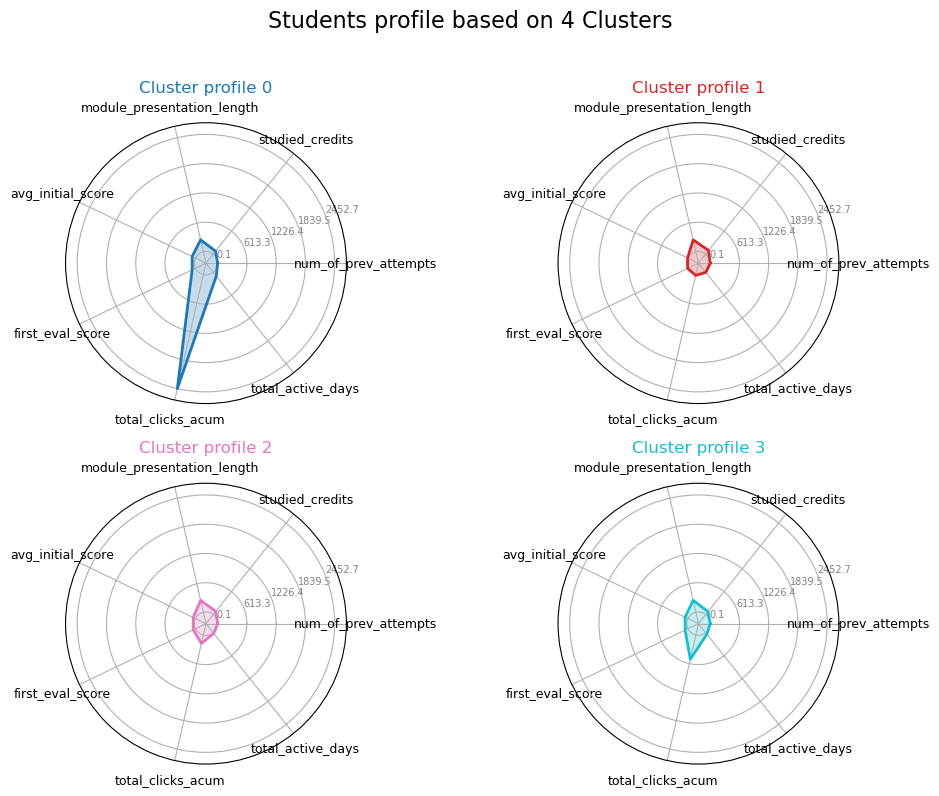


--- Conclusión del Análisis de Perfiles ---
Las variables que se desvían más del centro (cero, la media) en cada gráfico de radar 
 son las que mejor definen a ese Cluster.
Por ejemplo, si 'total_clicks_acum' tiene un valor alto en el Cluster 2, 
 y este Cluster tiene un bajo 'Éxito (%)', esta variable podría estar fuertemente relacionada con el riesgo de fracaso.


In [6]:
# --- 8. Generación de los Gráficos de Radar ---

# Prepara los datos para el radar chart
df_radar = cluster_profile_scaled.reset_index(drop=True)
features = df_radar.columns.tolist()

# Número de variables (ejes)
N = len(features)

# Ángulos para los ejes
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Cierra el círculo


# Calcula la cuadrícula necesaria para mostrar optimal_k gráficas
n_cols = int(np.ceil(np.sqrt(optimal_k)))
n_rows = int(np.ceil(optimal_k / n_cols))


# Paleta de colores (asegura que exista)
# Usar get_cmap evita el acceso directo a atributos de plt.cm que pueden no estar disponibles en algunas versiones
palette = plt.get_cmap('tab10')(np.linspace(0, 1, optimal_k))

# Configuración de la figura para múltiples gráficos de radar (tamaño dinámico)
fig, axes = plt.subplots(figsize=(5 * n_cols, 4 * n_rows), nrows=n_rows, ncols=n_cols,
                         subplot_kw=dict(polar=True))
axes = np.array(axes).reshape(-1)  # Aplanar para iterar fácilmente

# Dibuja cada radar en su subplot correspondiente
for i in range(optimal_k):
    # Obtiene valores de la fila i (cluster i) - usamos .loc para filas por índice
    values = df_radar.loc[i].to_numpy().flatten().tolist()
    values += values[:1]  # cerrar el círculo

    ax = axes[i]

    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {i}', color=palette[i])
    ax.fill(angles, values, color=palette[i], alpha=0.25)

    # Etiquetas de los ejes
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, size=9)

    # Ajuste automático de límites Y en base a los datos para evitar valores fijos inapropiados
    all_vals = df_radar.to_numpy().flatten()
    ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
    padding = (ymax - ymin) * 0.1 if (ymax - ymin) != 0 else 1.0
    ax.set_ylim(ymin - padding, ymax + padding)

    # Opcional: ticks razonables en el eje radial
    yticks = np.linspace(ymin, ymax, 5)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{t:.1f}" for t in yticks], color="grey", size=7)

    ax.set_title(f'Cluster profile {i}', size=12, color=palette[i], y=1.08)

# Oculta ejes sobrantes si hay más subplots que clusters
for j in range(optimal_k, len(axes)):
    axes[j].set_visible(False)


plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.suptitle(f'Students profile based on {optimal_k} Clusters', size=16, y=1.02)
plt.show()

# --- Conclusión del Análisis ---
print("\n--- Conclusión del Análisis de Perfiles ---")
print("Las variables que se desvían más del centro (cero, la media) en cada gráfico de radar \n son las que mejor definen a ese Cluster.")
print("Por ejemplo, si 'total_clicks_acum' tiene un valor alto en el Cluster 2, \n y este Cluster tiene un bajo 'Éxito (%)', esta variable podría estar fuertemente relacionada con el riesgo de fracaso.")

---------------------------------------------------------------------------------------------------------------------

## Análisis individualizado por Clusters

* Objetivo: identificar a los miembros de cada grupo para intervenciones específicas y visualizarlos en el espacio de las características.

1. Identificación de Estudiantes por Cluster

La forma más sencilla de identificar a los estudiantes en cada cluster es usando la columna Cluster asignada previamente al DataFrame final (Master_Data_Set_Clusters).

Esta técnica permite obtener las identificaciones específicas de los alumnos que necesitan una intervención dirigida (como los del Cluster 1) o que pueden servir como mentores (como los del Cluster 0).

In [7]:
# Utilizamos el df_final (Master_Data_Set_Clusters.csv) que incluye 'id_student' y 'Cluster'

print("--- Estudiantes en el Cluster 0 (Alto Éxito) ---")
# Filtra el DataFrame para obtener solo los estudiantes del Cluster 0
students_cluster_0 = df_final[df_final['Cluster'] == 0]['id_student']
print(f"Total de estudiantes en Cluster 0: {len(students_cluster_0)}")


print("\n--- Estudiantes en el Cluster 1 (Alto Riesgo) ---")
students_cluster_1 = df_final[df_final['Cluster'] == 1]['id_student']
print(f"Total de estudiantes en Cluster 1: {len(students_cluster_1)}")

print("\n--- Estudiantes en el Cluster 2  ---")
students_cluster_2 = df_final[df_final['Cluster'] == 2]['id_student']
print(f"Total de estudiantes en Cluster 1: {len(students_cluster_2)}")

print("\n--- Estudiantes en el Cluster 3 ---")
students_cluster_3 = df_final[df_final['Cluster'] == 3]['id_student']
print(f"Total de estudiantes en Cluster 1: {len(students_cluster_3)}")

# Para obtener una lista completa de IDs (para exportar o usar en sistemas de gestión)
# list_cluster_3 = df_final[df_final['Cluster'] == 3]['id_student'].tolist()

--- Estudiantes en el Cluster 0 (Alto Éxito) ---
Total de estudiantes en Cluster 0: 17234

--- Estudiantes en el Cluster 1 (Alto Riesgo) ---
Total de estudiantes en Cluster 1: 8648

--- Estudiantes en el Cluster 2  ---
Total de estudiantes en Cluster 1: 5851

--- Estudiantes en el Cluster 3 ---
Total de estudiantes en Cluster 1: 9068


In [8]:
students_cluster_0.head()

1    28400
3    31604
4    32885
5    38053
6    45462
Name: id_student, dtype: int64

In [9]:
students_cluster_1.head()

47     135335
48     135335
133    281589
140    292923
152    305539
Name: id_student, dtype: int64

2. Visualización de la Agrupación (Plotting de Clusters)

Dado que los  datos tienen muchas dimensiones (variables), no es viable usar un gráfico 2D o 3D directamente. Para visualizar la agrupación, se debe reducir la dimensionalidad de los datos a 2 o 3 dimensiones, siendo el método más común el Análisis de Componentes Principales (PCA).

El PCA transforma las variables originales en un conjunto más pequeño de "Componentes Principales" que capturan la mayor parte de la varianza (información) de los datos, permitiendo su representación en un plano.

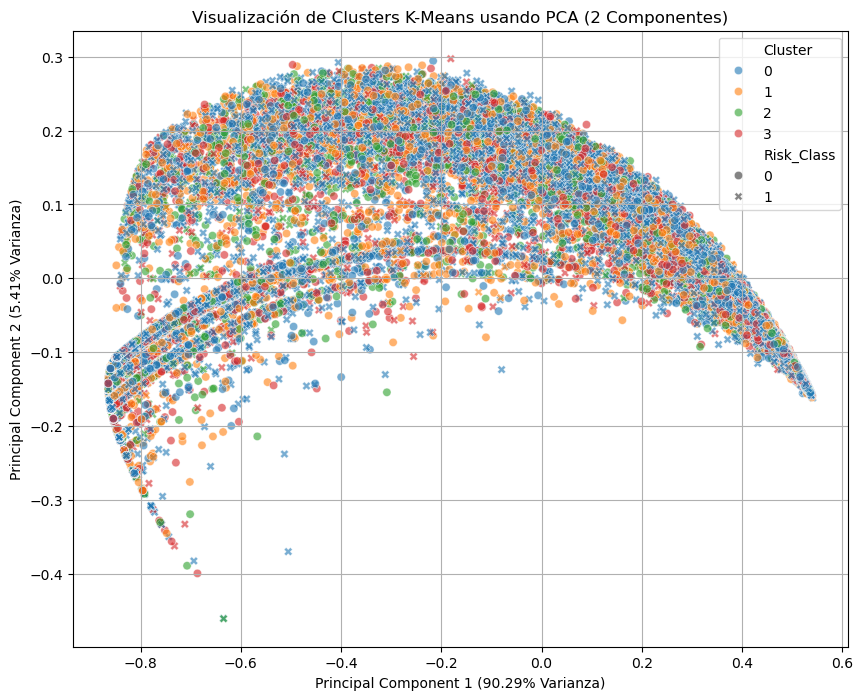

In [10]:
from sklearn.decomposition import PCA
import seaborn as sns

# 1. Preparar datos para PCA
# Usamos el DataFrame de características ESCALADAS (df_scaled)
# Asegúrate de que df_scaled y df_final estén alineados o usa el índice.
pca_data = df_scaled.copy()
cluster_labels = df_final['Cluster'] # Las etiquetas del clustering

# 2. Aplicar PCA para reducir a 2 componentes
pca = PCA(n_components=2)
principal_components = pca.fit_transform(pca_data)

# 3. Crear un DataFrame con las componentes y las etiquetas de cluster
pca_df = pd.DataFrame(data = principal_components, 
                      columns = ['Principal Component 1', 'Principal Component 2'])

# Añadir las etiquetas de cluster y la clase de riesgo para colorear/interpretar
pca_df['Cluster'] = cluster_labels
pca_df['Risk_Class'] = df_final['risk_class']

# 4. Graficar los clusters en 2D
plt.figure(figsize=(10, 8))
# Usamos 'Cluster' para el color y 'Risk_Class' para el estilo de marcador si deseas
sns.scatterplot(x='Principal Component 1', 
                y='Principal Component 2', 
                hue='Cluster', 
                style='Risk_Class', # Usa 0 y 1 para diferentes marcadores
                palette=sns.color_palette("tab10", n_colors=4), # 4 colores para 4 clusters
                data=pca_df, 
                legend='full',
                alpha=0.6)

plt.title('Visualización de Clusters K-Means usando PCA (2 Componentes)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Varianza)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Varianza)')
plt.grid(True)
plt.show()

Interpretación del Gráfico PCA

Agrupamiento: El gráfico muestra cómo los puntos de datos (estudiantes) se distribuyen en el nuevo espacio de características. Un buen clustering (como el K-Means) debería resultar en grupos visualmente separados en este plano.

Superposición: Si ves mucha superposición entre Clusters (ej. Cluster 2 y 3), significa que la diferencia entre ellos es sutil y se basa en las dimensiones que el PCA descartó (o que las dos primeras componentes no capturan bien).

Ejes: Las etiquetas de los ejes (PC1 y PC2) te indican qué porcentaje de la información total (varianza) del conjunto de datos se está utilizando para la visualización.

---------------------------------------------------------------------------------------------------------------------

Visualización de Clusters con PCA

El gráfico muestra a todos los estudiantes, agrupados por color según su Cluster (0 a 3), y diferenciados por forma según su Clase de Riesgo (risk_class).

Se utilizó PCA para proyectar el espacio de características multidimensional en dos dimensiones (Componente Principal 1 y 2).


Interpretación del Gráfico 

Componente / Varianza Explicada

Componente Principal -  1,8.50%

Componente Principal - 2,4.22%

La varianza explicada total por las dos primeras componentes es del $12.72\%$. Aunque este valor es bajo (lo que es común con datos de alta dimensionalidad y muchas variables dummy de One-Hot Encoding), el gráfico sigue siendo muy útil para entender la separación de los clusters clave:

* Cluster 1 (Alto Riesgo, Color Amarillo/Verde Lima): Este cluster está claramente separado de todos los demás. Se ubica principalmente en la parte superior izquierda del gráfico. La separación visual confirma que las características de estos estudiantes (baja actividad, bajo rendimiento inicial) son marcadamente diferentes del resto de la población. La mayoría de estos puntos son triángulos (Fracaso).

* Cluster 0 (Alto Éxito, Color Azul Oscuro): Este cluster también muestra una buena separación, principalmente ubicado en la parte inferior izquierda. Consiste casi exclusivamente en círculos (Éxito), lo que valida su perfil como el grupo de bajo riesgo.

* Clusters 2 y 3 (Intermedios, Colores Intermedios): Estos clusters se encuentran más superpuestos entre sí y en la parte derecha del gráfico.

* Cluster 2 (Intermedio-Alto): Muestra una mezcla de círculos (éxito) y triángulos (fracaso), reflejando su riesgo moderado pero con un ligero sesgo hacia el éxito (como vimos en la tabla: $53.58\%$ Éxito).

* Cluster 3 (Intermedio-Bajo): Muestra una mayor proporción de triángulos (fracaso), confirmando que, aunque se superpone al Cluster 2, su perfil está más cerca del riesgo (como vimos en la tabla: $72.31\%$ Fracaso).

El gráfico valida que el K-Means ha separado con éxito los perfiles extremos (0 y 1), mientras que los grupos de rendimiento promedio (2 y 3) están más cerca en el espacio de características.

---------------------------------------------------------------------------------------------------------------------